# Electromagnetic and Hadronic Shower Calculator

This notebook calculates **electromagnetic (EM) and hadronic shower parameters** in different materials, including:

## Features

⚡ **Electromagnetic Showers**: Radiation length, Molière radius, critical energy, shower profiles

🎯 **Hadronic Showers**: Nuclear interaction length, shower development, fluctuations

🎛️ **Material Parameters**: Easy selection of detector materials (lead, iron, plastic, etc.)

📊 **Shower Profiles**: Longitudinal and lateral shower development

🔢 **Particle Counting**: Number of particles vs depth and energy

## Key Physics

### Electromagnetic Showers:
- **Radiation Length** (X₀): Characteristic length for bremsstrahlung and pair production
- **Molière Radius** (RM): Transverse containment radius  
- **Critical Energy** (Ec): Energy where ionization = radiation losses
- **Shower Maximum**: Depth of maximum particle production

### Hadronic Showers:
- **Nuclear Interaction Length** (λI): Mean free path for nuclear interactions
- **Shower Development**: More complex due to π⁰ → γγ cascades
- **Fluctuations**: Larger variations than EM showers

---

**📝 Instructions**: Modify the `material` parameter below, then run all cells!

In [1]:
# ===================================================================
# IMPORTS AND CONFIGURATION
# ===================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as gamma_func
from scipy.integrate import quad
import warnings
warnings.filterwarnings('ignore')

# Material properties database for shower calculations
MATERIALS = {
    'lead': {
        'Z': 82, 'A': 207.2, 'density': 11.34,  # g/cm³
        'X0': 0.56, 'lambda_I': 17.1,           # cm (radiation length, nuclear interaction length)
        'Ec': 7.43,                             # MeV (critical energy)
        'color': '#C73E1D'
    },
    'iron': {
        'Z': 26, 'A': 55.845, 'density': 7.87,
        'X0': 1.76, 'lambda_I': 16.8, 
        'Ec': 21.8,
        'color': '#F18F01'
    },
    'aluminum': {
        'Z': 13, 'A': 26.98, 'density': 2.70,
        'X0': 8.90, 'lambda_I': 38.4,
        'Ec': 42.7,
        'color': '#A23B72'
    },
    'copper': {
        'Z': 29, 'A': 63.55, 'density': 8.96,
        'X0': 1.43, 'lambda_I': 15.1,
        'Ec': 19.6,
        'color': '#E67E22'
    },
    'plastic': {
        'Z': 6, 'A': 12.01, 'density': 1.03,     # Typical organic plastic
        'X0': 42.7, 'lambda_I': 79.5,
        'Ec': 81.2,
        'color': '#2E86AB'
    },
    'tungsten': {
        'Z': 74, 'A': 183.8, 'density': 19.3,
        'X0': 0.35, 'lambda_I': 9.6,
        'Ec': 7.97,
        'color': '#8E44AD'
    },
    'concrete': {
        'Z': 11, 'A': 22, 'density': 2.3,        # Effective values
        'X0': 10.7, 'lambda_I': 39.3,
        'Ec': 49.2,
        'color': '#27AE60'
    }
}

# Select material (CHANGE THIS PARAMETER!)
material = 'lead'  # Options: 'lead', 'iron', 'aluminum', 'copper', 'plastic', 'tungsten', 'concrete'

print(f"🎯 Calculating shower parameters in {material.upper()}")
print(f"📋 Available materials: {list(MATERIALS.keys())}")

🎯 Calculating shower parameters in LEAD
📋 Available materials: ['lead', 'iron', 'aluminum', 'copper', 'plastic', 'tungsten', 'concrete']


In [2]:
# ===================================================================
# ELECTROMAGNETIC SHOWER PHYSICS
# ===================================================================

def calculate_moliere_radius(X0, Z, A, density):
    """
    Calculate Molière radius for electromagnetic showers.
    RM = X0 * (Es/Ec) where Es ≈ 21.2 MeV
    """
    Es = 21.2  # MeV (scale energy)
    Ec = calculate_critical_energy(Z)
    RM = X0 * (Es / Ec)
    return RM

def calculate_critical_energy(Z):
    """
    Calculate critical energy where radiation losses = ionization losses.
    Empirical formula: Ec ≈ 610 MeV / (Z + 1.24)
    """
    Ec = 610.0 / (Z + 1.24)  # MeV
    return Ec

def em_shower_maximum(E0, Ec, X0):
    """
    Calculate shower maximum depth in radiation lengths.
    tmax ≈ ln(E0/Ec) - 0.5 for electrons
    tmax ≈ ln(E0/Ec) + 0.5 for photons
    """
    if E0 <= Ec:
        return 0.5  # Minimum depth
    
    tmax_electron = np.log(E0 / Ec) - 0.5
    tmax_photon = np.log(E0 / Ec) + 0.5
    
    return tmax_electron, tmax_photon

def em_longitudinal_profile(t, tmax, s=0.5):
    """
    Longitudinal shower profile (number of particles vs depth).
    Uses gamma distribution: N(t) ∝ t^(tmax-1) * exp(-t/s)
    
    Parameters:
    t: depth in radiation lengths
    tmax: shower maximum depth
    s: shower width parameter
    """
    if tmax < 1:
        tmax = 1  # Avoid negative values
    
    # Gamma distribution for shower profile
    a = tmax / s  # Shape parameter
    profile = (t / s)**(a - 1) * np.exp(-t / s)
    
    # Normalize to peak at tmax
    profile = profile / np.max(profile)
    
    return profile

def em_lateral_profile(r, RM):
    """
    Lateral shower profile (radial distribution).
    Approximate Molière distribution.
    
    Parameters:
    r: radial distance from shower axis (cm)
    RM: Molière radius (cm)
    """
    # Simplified Molière profile
    profile = np.exp(-(r / RM)**2 / 2) * (1 + (r / RM)**2 / 8)
    
    return profile

def em_total_particles(E0, Ec):
    """
    Estimate total number of particles in EM shower at maximum.
    Nmax ≈ E0 / Ec (for E0 >> Ec)
    """
    if E0 <= Ec:
        return 1  # Single particle
    
    Nmax = E0 / Ec
    return Nmax

print("✓ Electromagnetic shower functions loaded")

✓ Electromagnetic shower functions loaded


In [3]:
# ===================================================================
# HADRONIC SHOWER PHYSICS
# ===================================================================

def hadronic_shower_development(E0, lambda_I, f_em=0.3):
    """
    Model hadronic shower development.
    Hadronic showers have electromagnetic component from π⁰ → γγ
    
    Parameters:
    E0: Initial hadron energy (MeV)
    lambda_I: Nuclear interaction length (cm)  
    f_em: Electromagnetic fraction (typically ~30%)
    """
    
    # Energy in electromagnetic and hadronic components
    E_em = f_em * E0  # EM component from π⁰ decays
    E_had = (1 - f_em) * E0  # Pure hadronic component
    
    # Shower maximum for hadronic component
    # Empirical: tmax ≈ 0.2 * ln(E0/GeV) + 0.7 (in interaction lengths)
    E0_GeV = E0 / 1000.0  # Convert to GeV
    if E0_GeV < 1:
        tmax_had = 1.0
    else:
        tmax_had = 0.2 * np.log(E0_GeV) + 0.7
    
    return E_em, E_had, tmax_had

def hadronic_longitudinal_profile(t, tmax_had, sigma_had=0.8):
    """
    Longitudinal profile for hadronic showers.
    More spread out than EM showers.
    
    Parameters:
    t: depth in interaction lengths
    tmax_had: shower maximum depth
    sigma_had: shower width (larger than EM)
    """
    
    # Hadronic showers are broader than EM
    profile = np.exp(-0.5 * ((t - tmax_had) / sigma_had)**2)
    
    # Add tail for late interactions
    tail = 0.1 * np.exp(-t / (3 * tmax_had))
    
    total_profile = profile + tail
    
    # Normalize
    total_profile = total_profile / np.max(total_profile)
    
    return total_profile

def hadronic_lateral_profile(r, lambda_I):
    """
    Lateral profile for hadronic showers.
    Broader than EM showers due to nuclear interactions.
    
    Parameters:
    r: radial distance (cm)
    lambda_I: nuclear interaction length (cm)
    """
    
    # Hadronic shower radius ~ λI/3
    R_had = lambda_I / 3.0
    
    # Broader profile than EM
    profile = np.exp(-(r / R_had)**1.5 / 2)
    
    return profile

def shower_fluctuations(N_particles, shower_type='em'):
    """
    Calculate shower fluctuations.
    
    Parameters:
    N_particles: Average number of particles
    shower_type: 'em' or 'hadronic'
    """
    
    if shower_type == 'em':
        # EM showers: σ/N ≈ 1/√N (Poisson)
        fluctuation = 1.0 / np.sqrt(N_particles)
    else:
        # Hadronic showers: larger fluctuations
        # σ/N ≈ 0.5/√N due to π⁰ fraction variations
        fluctuation = 0.5 / np.sqrt(N_particles)
    
    return fluctuation

print("✓ Hadronic shower functions loaded")

✓ Hadronic shower functions loaded


In [4]:
# ===================================================================
# CALCULATE SHOWER PARAMETERS FOR SELECTED MATERIAL
# ===================================================================

# Get material properties
mat_props = MATERIALS[material]
Z = mat_props['Z']
A = mat_props['A']
density = mat_props['density']
X0 = mat_props['X0']  # cm
lambda_I = mat_props['lambda_I']  # cm
Ec_tabulated = mat_props['Ec']  # MeV

print(f"📊 MATERIAL PROPERTIES: {material.upper()}")
print("=" * 50)
print(f"Atomic number (Z): {Z}")
print(f"Atomic mass (A): {A:.2f} g/mol")
print(f"Density (ρ): {density:.2f} g/cm³")
print(f"Radiation length (X₀): {X0:.2f} cm")
print(f"Nuclear interaction length (λI): {lambda_I:.1f} cm")
print(f"Critical energy (Ec): {Ec_tabulated:.1f} MeV")

# Calculate derived parameters
Ec_calc = calculate_critical_energy(Z)
RM = calculate_moliere_radius(X0, Z, A, density)

print(f"\n📏 CALCULATED EM SHOWER PARAMETERS:")
print("-" * 40)
print(f"Critical energy (calculated): {Ec_calc:.1f} MeV")
print(f"Molière radius (RM): {RM:.2f} cm")
print(f"RM/X₀ ratio: {RM/X0:.2f}")
print(f"λI/X₀ ratio: {lambda_I/X0:.1f}")

# Energy range for shower calculations
test_energies = [100, 1000, 10000]  # MeV

print(f"\n⚡ EM SHOWER CHARACTERISTICS:")
print("-" * 40)
for E0 in test_energies:
    if E0 > Ec_tabulated:
        tmax_e, tmax_gamma = em_shower_maximum(E0, Ec_tabulated, X0)
        N_total = em_total_particles(E0, Ec_tabulated)
        fluct = shower_fluctuations(N_total, 'em')
        
        print(f"  {E0/1000:.1f} GeV: tmax = {tmax_e:.1f} X₀ ({tmax_e*X0:.1f} cm), N ≈ {N_total:.0f}, σ/N = {fluct:.3f}")

print(f"\n🎯 HADRONIC SHOWER CHARACTERISTICS:")
print("-" * 40)
for E0 in test_energies:
    E_em, E_had, tmax_had = hadronic_shower_development(E0, lambda_I)
    N_total_had = E0 / 50  # Rough estimate: ~50 MeV per particle
    fluct_had = shower_fluctuations(N_total_had, 'hadronic')
    
    print(f"  {E0/1000:.1f} GeV: tmax = {tmax_had:.1f} λI ({tmax_had*lambda_I:.1f} cm), EM frac = {E_em/E0:.1%}, σ/N = {fluct_had:.3f}")

print(f"\n✓ Shower parameters calculated for {material}")

📊 MATERIAL PROPERTIES: LEAD
Atomic number (Z): 82
Atomic mass (A): 207.20 g/mol
Density (ρ): 11.34 g/cm³
Radiation length (X₀): 0.56 cm
Nuclear interaction length (λI): 17.1 cm
Critical energy (Ec): 7.4 MeV

📏 CALCULATED EM SHOWER PARAMETERS:
----------------------------------------
Critical energy (calculated): 7.3 MeV
Molière radius (RM): 1.62 cm
RM/X₀ ratio: 2.89
λI/X₀ ratio: 30.5

⚡ EM SHOWER CHARACTERISTICS:
----------------------------------------
  0.1 GeV: tmax = 2.1 X₀ (1.2 cm), N ≈ 13, σ/N = 0.273
  1.0 GeV: tmax = 4.4 X₀ (2.5 cm), N ≈ 135, σ/N = 0.086
  10.0 GeV: tmax = 6.7 X₀ (3.8 cm), N ≈ 1346, σ/N = 0.027

🎯 HADRONIC SHOWER CHARACTERISTICS:
----------------------------------------
  0.1 GeV: tmax = 1.0 λI (17.1 cm), EM frac = 30.0%, σ/N = 0.354
  1.0 GeV: tmax = 0.7 λI (12.0 cm), EM frac = 30.0%, σ/N = 0.112
  10.0 GeV: tmax = 1.2 λI (19.8 cm), EM frac = 30.0%, σ/N = 0.035

✓ Shower parameters calculated for lead


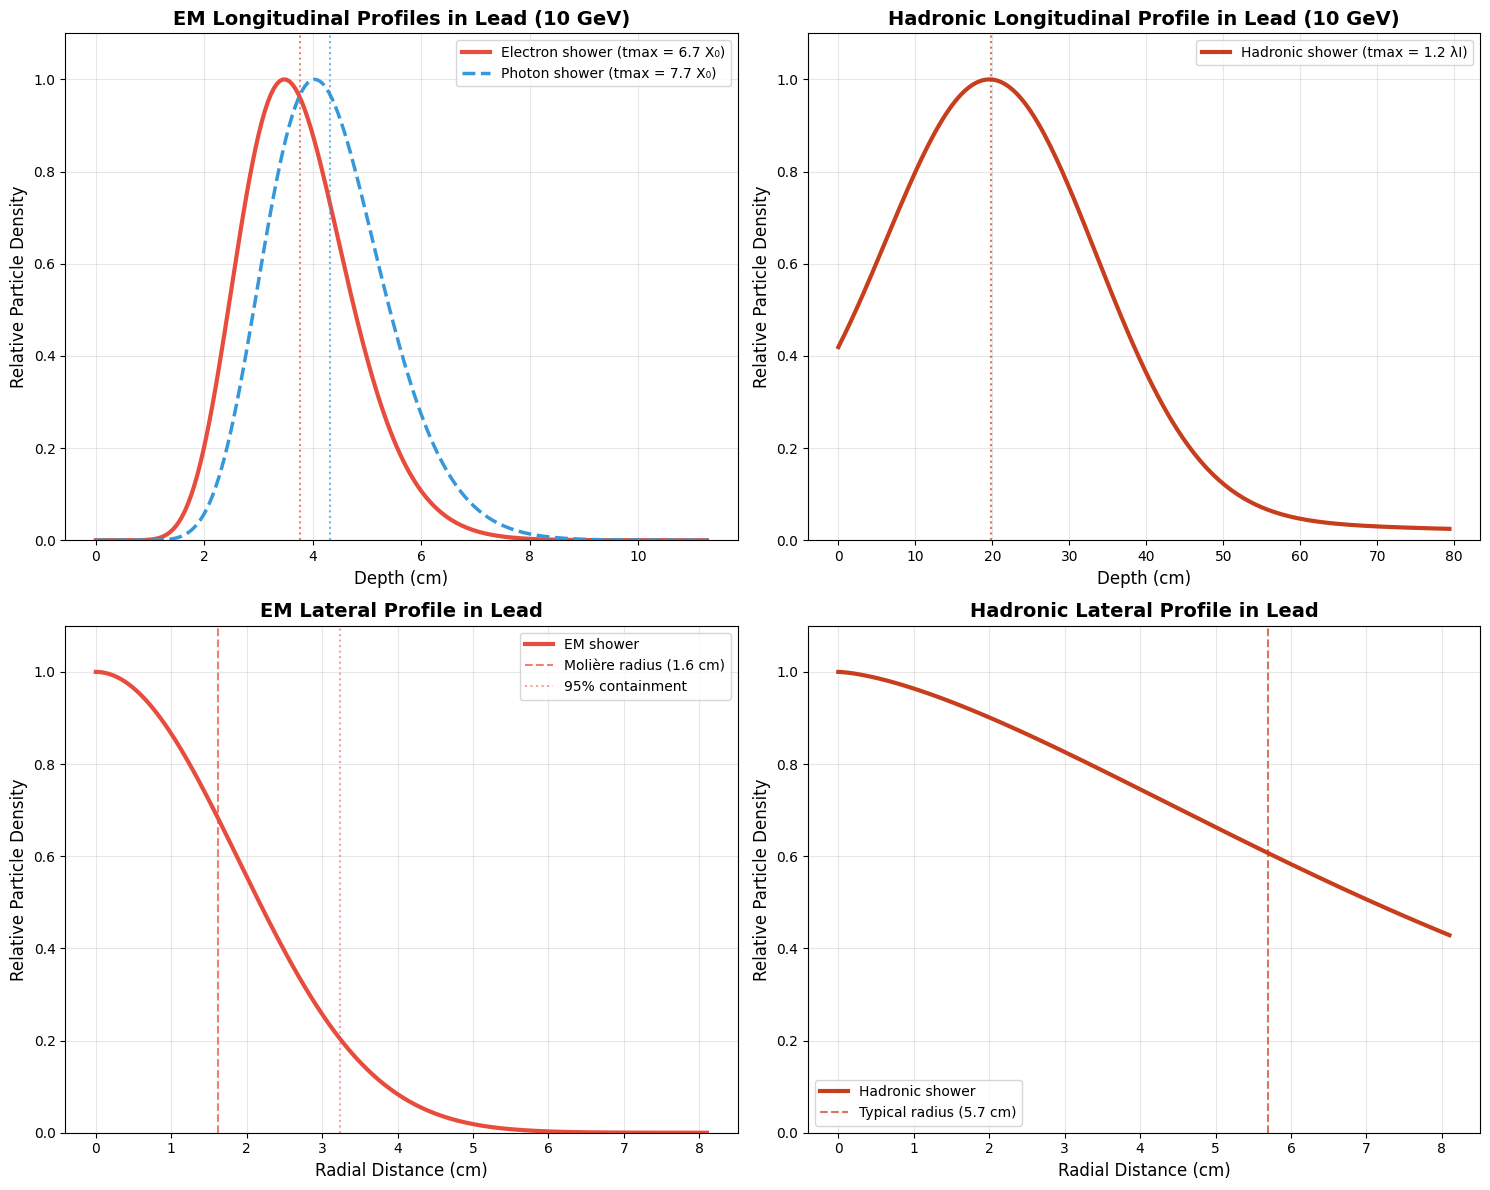

📈 Shower profiles plotted for lead


In [5]:
# ===================================================================
# PLOT 1: LONGITUDINAL SHOWER PROFILES
# ===================================================================

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Test energy for detailed profiles
E_test = 10000  # MeV (10 GeV)

# EM shower longitudinal profile
if E_test > Ec_tabulated:
    tmax_e, tmax_gamma = em_shower_maximum(E_test, Ec_tabulated, X0)
    
    # Depth arrays
    t_em = np.linspace(0, 3 * tmax_e, 200)  # In X₀ units
    depth_em_cm = t_em * X0  # Convert to cm
    
    # Profiles
    profile_e = em_longitudinal_profile(t_em, tmax_e)
    profile_gamma = em_longitudinal_profile(t_em, tmax_gamma)
    
    ax1.plot(depth_em_cm, profile_e, '-', linewidth=3, 
            label=f'Electron shower (tmax = {tmax_e:.1f} X₀)', color='#E74C3C')
    ax1.plot(depth_em_cm, profile_gamma, '--', linewidth=2.5, 
            label=f'Photon shower (tmax = {tmax_gamma:.1f} X₀)', color='#3498DB')
    
    ax1.axvline(tmax_e * X0, color='#E74C3C', linestyle=':', alpha=0.7)
    ax1.axvline(tmax_gamma * X0, color='#3498DB', linestyle=':', alpha=0.7)

ax1.set_xlabel('Depth (cm)', fontsize=12)
ax1.set_ylabel('Relative Particle Density', fontsize=12)
ax1.set_title(f'EM Longitudinal Profiles in {material.title()} ({E_test/1000:.0f} GeV)', 
              fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.1)

# Hadronic shower longitudinal profile
E_em, E_had, tmax_had = hadronic_shower_development(E_test, lambda_I)

t_had = np.linspace(0, 4 * tmax_had, 200)  # In λI units
depth_had_cm = t_had * lambda_I  # Convert to cm

profile_had = hadronic_longitudinal_profile(t_had, tmax_had)

ax2.plot(depth_had_cm, profile_had, '-', linewidth=3, 
        label=f'Hadronic shower (tmax = {tmax_had:.1f} λI)', 
        color=mat_props['color'])
ax2.axvline(tmax_had * lambda_I, color=mat_props['color'], 
           linestyle=':', alpha=0.7)

ax2.set_xlabel('Depth (cm)', fontsize=12)
ax2.set_ylabel('Relative Particle Density', fontsize=12)
ax2.set_title(f'Hadronic Longitudinal Profile in {material.title()} ({E_test/1000:.0f} GeV)', 
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.1)

# Lateral profiles
r_max = 5 * RM  # Radial range
r = np.linspace(0, r_max, 200)

# EM lateral profile
lateral_em = em_lateral_profile(r, RM)
ax3.plot(r, lateral_em, '-', linewidth=3, label='EM shower', color='#E74C3C')
ax3.axvline(RM, color='#E74C3C', linestyle='--', alpha=0.7, label=f'Molière radius ({RM:.1f} cm)')
ax3.axvline(2*RM, color='#E74C3C', linestyle=':', alpha=0.5, label='95% containment')

ax3.set_xlabel('Radial Distance (cm)', fontsize=12)
ax3.set_ylabel('Relative Particle Density', fontsize=12)
ax3.set_title(f'EM Lateral Profile in {material.title()}', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.1)

# Hadronic lateral profile
lateral_had = hadronic_lateral_profile(r, lambda_I)
R_had_typical = lambda_I / 3.0

ax4.plot(r, lateral_had, '-', linewidth=3, label='Hadronic shower', 
        color=mat_props['color'])
ax4.axvline(R_had_typical, color=mat_props['color'], linestyle='--', alpha=0.7, 
           label=f'Typical radius ({R_had_typical:.1f} cm)')

ax4.set_xlabel('Radial Distance (cm)', fontsize=12)
ax4.set_ylabel('Relative Particle Density', fontsize=12)
ax4.set_title(f'Hadronic Lateral Profile in {material.title()}', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

print(f"📈 Shower profiles plotted for {material}")

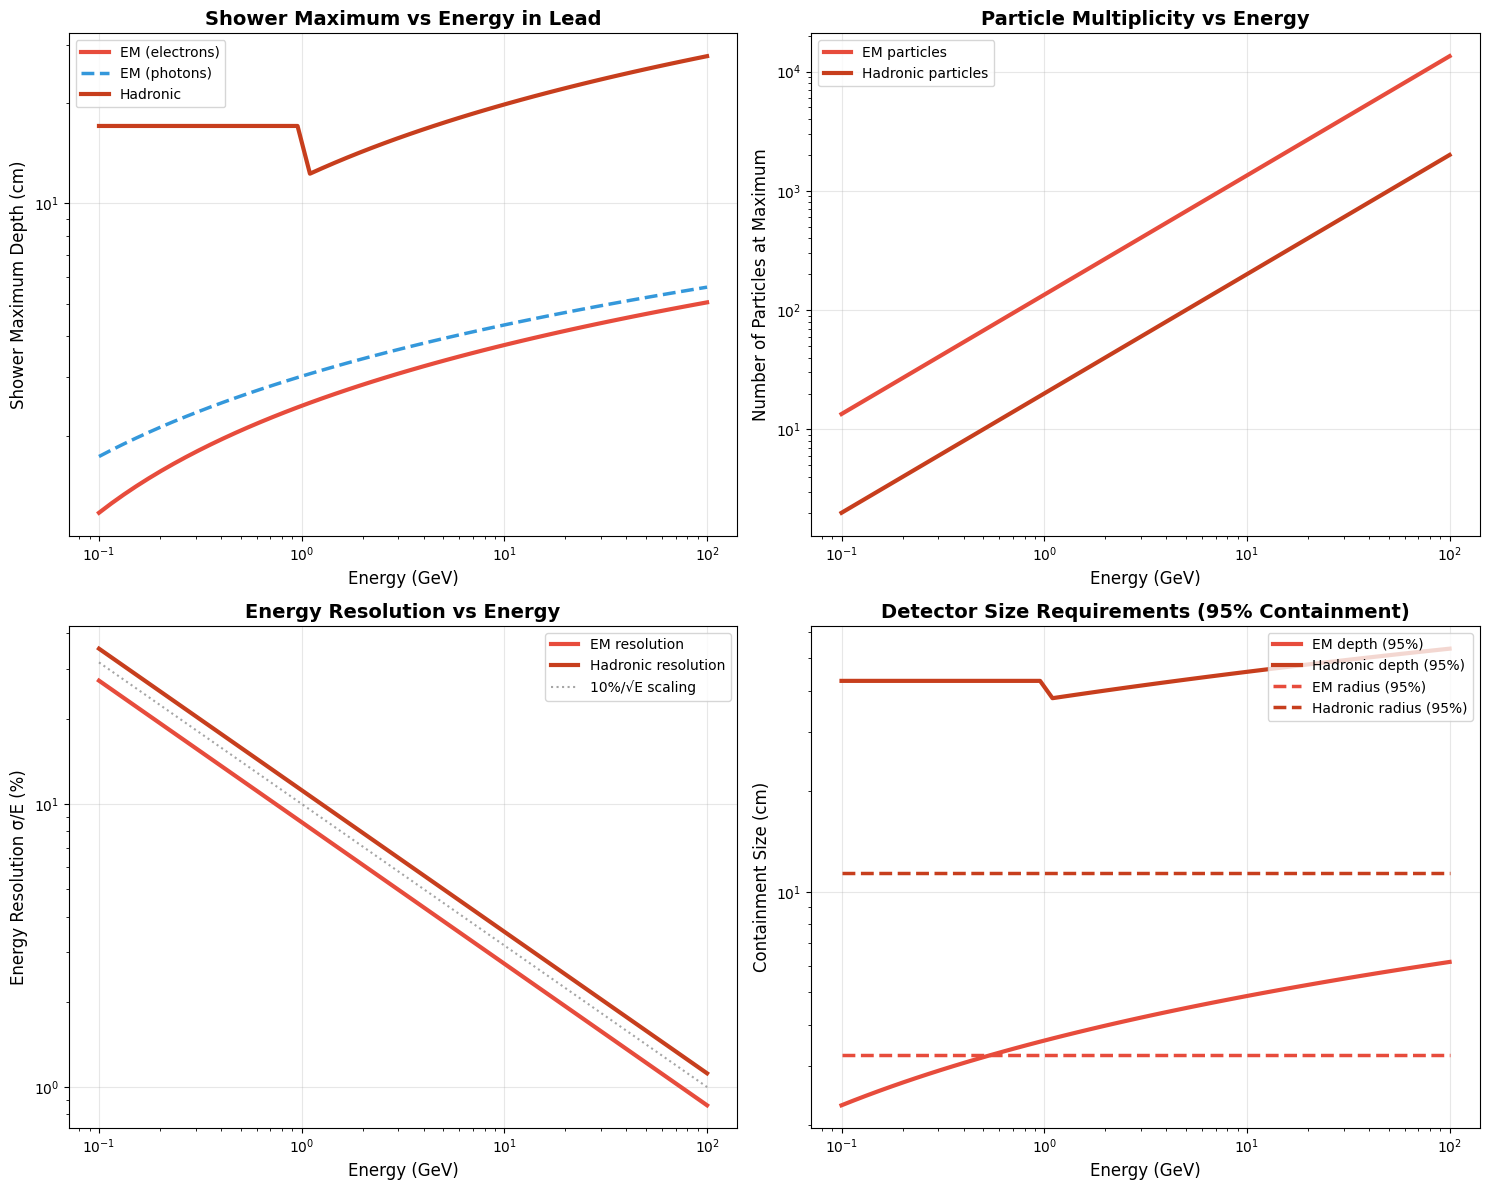

📊 Energy scaling plots created for lead


In [6]:
# ===================================================================
# PLOT 2: SHOWER DEVELOPMENT VS ENERGY
# ===================================================================

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Energy range for scaling studies
energies = np.logspace(2, 5, 50)  # 100 MeV to 100 GeV

# Calculate shower parameters vs energy
tmax_electrons = []
tmax_photons = []
tmax_hadrons = []
N_em_particles = []
N_had_particles = []
em_fluctuations = []
had_fluctuations = []

for E in energies:
    # EM showers
    if E > Ec_tabulated:
        tmax_e, tmax_g = em_shower_maximum(E, Ec_tabulated, X0)
        N_em = em_total_particles(E, Ec_tabulated)
        fluct_em = shower_fluctuations(N_em, 'em')
    else:
        tmax_e = tmax_g = 0.5
        N_em = 1
        fluct_em = 1.0
    
    tmax_electrons.append(tmax_e)
    tmax_photons.append(tmax_g)
    N_em_particles.append(N_em)
    em_fluctuations.append(fluct_em)
    
    # Hadronic showers
    E_em_comp, E_had_comp, tmax_h = hadronic_shower_development(E, lambda_I)
    N_had = E / 50  # Rough estimate
    fluct_had = shower_fluctuations(N_had, 'hadronic')
    
    tmax_hadrons.append(tmax_h)
    N_had_particles.append(N_had)
    had_fluctuations.append(fluct_had)

# Convert to arrays
energies_gev = energies / 1000
tmax_electrons = np.array(tmax_electrons)
tmax_photons = np.array(tmax_photons)
tmax_hadrons = np.array(tmax_hadrons)
N_em_particles = np.array(N_em_particles)
N_had_particles = np.array(N_had_particles)
em_fluctuations = np.array(em_fluctuations)
had_fluctuations = np.array(had_fluctuations)

# Plot 1: Shower maximum depth vs energy
ax1.loglog(energies_gev, tmax_electrons * X0, '-', linewidth=3, 
          label='EM (electrons)', color='#E74C3C')
ax1.loglog(energies_gev, tmax_photons * X0, '--', linewidth=2.5, 
          label='EM (photons)', color='#3498DB')
ax1.loglog(energies_gev, tmax_hadrons * lambda_I, '-', linewidth=3, 
          label='Hadronic', color=mat_props['color'])

ax1.set_xlabel('Energy (GeV)', fontsize=12)
ax1.set_ylabel('Shower Maximum Depth (cm)', fontsize=12)
ax1.set_title(f'Shower Maximum vs Energy in {material.title()}', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Number of particles vs energy
ax2.loglog(energies_gev, N_em_particles, '-', linewidth=3, 
          label='EM particles', color='#E74C3C')
ax2.loglog(energies_gev, N_had_particles, '-', linewidth=3, 
          label='Hadronic particles', color=mat_props['color'])

ax2.set_xlabel('Energy (GeV)', fontsize=12)
ax2.set_ylabel('Number of Particles at Maximum', fontsize=12)
ax2.set_title(f'Particle Multiplicity vs Energy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Energy resolution (fluctuations)
ax3.loglog(energies_gev, em_fluctuations * 100, '-', linewidth=3, 
          label='EM resolution', color='#E74C3C')
ax3.loglog(energies_gev, had_fluctuations * 100, '-', linewidth=3, 
          label='Hadronic resolution', color=mat_props['color'])

# Add theoretical scaling lines
scaling_1_sqrt_E = 10 / np.sqrt(energies_gev)  # 10%/√E
ax3.loglog(energies_gev, scaling_1_sqrt_E, ':', color='gray', alpha=0.7, 
          label='10%/√E scaling')

ax3.set_xlabel('Energy (GeV)', fontsize=12)
ax3.set_ylabel('Energy Resolution σ/E (%)', fontsize=12)
ax3.set_title(f'Energy Resolution vs Energy', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Shower containment requirements
# Depth required for 95% shower containment
depth_95_em = (tmax_electrons + 2) * X0  # Rough estimate
depth_95_had = (tmax_hadrons + 1.5) * lambda_I

# Radius required for 95% containment
radius_95_em = np.full_like(energies_gev, 2 * RM)  # 2 Molière radii
radius_95_had = np.full_like(energies_gev, 2 * lambda_I / 3)  # Broader for hadronic

ax4.loglog(energies_gev, depth_95_em, '-', linewidth=3, 
          label='EM depth (95%)', color='#E74C3C')
ax4.loglog(energies_gev, depth_95_had, '-', linewidth=3, 
          label='Hadronic depth (95%)', color=mat_props['color'])
ax4.loglog(energies_gev, radius_95_em, '--', linewidth=2.5, 
          label='EM radius (95%)', color='#E74C3C')
ax4.loglog(energies_gev, radius_95_had, '--', linewidth=2.5, 
          label='Hadronic radius (95%)', color=mat_props['color'])

ax4.set_xlabel('Energy (GeV)', fontsize=12)
ax4.set_ylabel('Containment Size (cm)', fontsize=12)
ax4.set_title(f'Detector Size Requirements (95% Containment)', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Energy scaling plots created for {material}")

In [7]:
# ===================================================================
# MATERIAL COMPARISON AND SUMMARY
# ===================================================================

print("\n" + "="*80)
print(f"🎯 COMPREHENSIVE SHOWER ANALYSIS: {material.upper()}")
print("="*80)

# Key parameters summary
test_E = 10000  # MeV (10 GeV) for examples

if test_E > Ec_tabulated:
    tmax_e_10gev, tmax_g_10gev = em_shower_maximum(test_E, Ec_tabulated, X0)
    N_em_10gev = em_total_particles(test_E, Ec_tabulated)
    
E_em_10gev, E_had_10gev, tmax_h_10gev = hadronic_shower_development(test_E, lambda_I)
N_had_10gev = test_E / 50

print(f"📋 MATERIAL PARAMETERS:")
print(f"   Radiation length (X₀): {X0:.2f} cm")
print(f"   Nuclear interaction length (λI): {lambda_I:.1f} cm")
print(f"   Critical energy (Ec): {Ec_tabulated:.1f} MeV")
print(f"   Molière radius (RM): {RM:.2f} cm")
print(f"   Density: {density:.2f} g/cm³")

print(f"\n⚡ EM SHOWER (10 GeV):")
print(f"   Shower maximum: {tmax_e_10gev:.1f} X₀ = {tmax_e_10gev * X0:.1f} cm")
print(f"   Peak particles: ~{N_em_10gev:.0f}")
print(f"   95% containment: ~{2*RM:.1f} cm radius, ~{(tmax_e_10gev + 2)*X0:.1f} cm depth")
print(f"   Energy resolution: ~{100/np.sqrt(N_em_10gev):.1f}%")

print(f"\n🎯 HADRONIC SHOWER (10 GeV):")
print(f"   Shower maximum: {tmax_h_10gev:.1f} λI = {tmax_h_10gev * lambda_I:.1f} cm")
print(f"   EM fraction: ~{E_em_10gev/test_E:.1%}")
print(f"   Peak particles: ~{N_had_10gev:.0f}")
print(f"   95% containment: ~{2*lambda_I/3:.1f} cm radius, ~{(tmax_h_10gev + 1.5)*lambda_I:.1f} cm depth")
print(f"   Energy resolution: ~{50/np.sqrt(N_had_10gev):.1f}%")

print(f"\n🔬 PHYSICS INSIGHTS:")
print(f"   • X₀/λI ratio: {X0/lambda_I:.3f} (smaller = denser material)")
print(f"   • RM/X₀ ratio: {RM/X0:.2f} (transverse vs longitudinal scale)")
if X0 < 1:
    print(f"   • Very dense material → compact EM showers")
elif X0 > 20:
    print(f"   • Light material → extended EM showers")
else:
    print(f"   • Intermediate density material")

print(f"\n🛠️ DETECTOR DESIGN IMPLICATIONS:")
print(f"   • EM calorimeter depth needed: ~{15*X0:.1f} cm ({15:.0f} X₀)")
print(f"   • Hadronic calorimeter depth needed: ~{8*lambda_I:.1f} cm ({8:.0f} λI)")
print(f"   • Transverse segmentation: ~{RM/2:.1f} cm (RM/2) for EM")
if lambda_I < 20:
    print(f"   • Dense material → good for compact calorimeters")
else:
    print(f"   • Light material → requires larger detectors")

print(f"\n💡 TO CHANGE MATERIAL:")
print(f"   Modify 'material' parameter: {list(MATERIALS.keys())}")
print(f"   Current selection: '{material}'")

print("="*80)


🎯 COMPREHENSIVE SHOWER ANALYSIS: LEAD
📋 MATERIAL PARAMETERS:
   Radiation length (X₀): 0.56 cm
   Nuclear interaction length (λI): 17.1 cm
   Critical energy (Ec): 7.4 MeV
   Molière radius (RM): 1.62 cm
   Density: 11.34 g/cm³

⚡ EM SHOWER (10 GeV):
   Shower maximum: 6.7 X₀ = 3.8 cm
   Peak particles: ~1346
   95% containment: ~3.2 cm radius, ~4.9 cm depth
   Energy resolution: ~2.7%

🎯 HADRONIC SHOWER (10 GeV):
   Shower maximum: 1.2 λI = 19.8 cm
   EM fraction: ~30.0%
   Peak particles: ~200
   95% containment: ~11.4 cm radius, ~45.5 cm depth
   Energy resolution: ~3.5%

🔬 PHYSICS INSIGHTS:
   • X₀/λI ratio: 0.033 (smaller = denser material)
   • RM/X₀ ratio: 2.89 (transverse vs longitudinal scale)
   • Very dense material → compact EM showers

🛠️ DETECTOR DESIGN IMPLICATIONS:
   • EM calorimeter depth needed: ~8.4 cm (15 X₀)
   • Hadronic calorimeter depth needed: ~136.8 cm (8 λI)
   • Transverse segmentation: ~0.8 cm (RM/2) for EM
   • Dense material → good for compact calorimet